In [107]:
from ngsolve import *
import numpy as np
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
from ngsolve.meshes import Make1DMesh
from math import isnan
import time
from ngsolve.nonlinearsolvers import Newton

ngsglobals.msg_level = 0
%matplotlib notebook
import warnings
warnings.filterwarnings('ignore')

In [165]:
def Mixed(
    n0 = 20,
    m = 2,
    s0 = 3,
    order = 1,
    dt0 = 0.01,
    tstart = Parameter(0),
    tstop = 4,
    plot = 0,
    IC = 1,
):
    tau = Parameter(dt0)
    
    rho_ex = IfPos((x-np.pi/2)*(x+np.pi/2), 0, ((m-1)/m*cos(x)**2)**(1/(m-1)) )
    xmin, xmax = -3, 3
    tWait = 1/2/(m+1)
        
    mesh = Make1DMesh(n=n0, mapping=lambda x:xmin+(xmax-xmin)*x)
    h0 = (xmax-xmin)/n0

    pnts_x = np.linspace(xmin+0.5*h0,xmax-0.5*h0,n0)
    
        
    V = L2(mesh) # density
    W = H1(mesh) # velocity
    fes = FESpace([V, W])
    
    (rho, u), (eta, v) = fes.TnT()    
    
    gfu = GridFunction(fes)
    rhoh, uh = gfu.components
    rhoh0 = GridFunction(V) # previous den
    rhoh1 = GridFunction(W) # average den
    
    # Used for plotting
    rhoWT = GridFunction(V)
    rhoInit = GridFunction(V)
    
    # the nonlinear operator
    a  = BilinearForm(fes)
    n = specialcf.normal(mesh.dim)
    flux = u*n*IfPos(u*n, rhoh0, 2*rhoh1-rhoh0)
    
    # mass
    a += (rho-rhoh0)/tau*eta*dx
    a += flux*eta*dx(element_boundary=True)
    # vel
    ir = IntegrationRule(points = [(0,0), (1,0)], weights = [1/2, 1/2] )
    a += u*v*dx(intrules={SEGM:ir})    
    p = m/(m-1)*rho**(m-1)
    # linearize pres
#     p = m/(m-1)*rhoh0**(m-1)+ m*rhoh0**(m-2)*(rho-rhoh0)
    a += -p*grad(v)*dx
    
    # only used to set up initial data
    def getU():
        rho0 = rhoh.vec.FV().NumPy()        
        p0 = m/(m-1)*rho0**(m-1)
        uh.vec.FV().NumPy()[1:-1] = (p0[:-1]-p0[1:])/h0
   
    iteration = 0
    # initial data: L2-projection
    rhoh.Set(rho_ex)
    getU()
    rhoh1.Set(rhoh)
        
        
    with TaskManager():
        pnts_t = []
        pnts_xR = []
        while tstart.Get() < tstop - tau.Get()/2:
            iteration += 1
            dt = tau.Get()
            tstart.Set(tstart.Get()+dt)                
            # apply RHS
            rhoh0.vec.data = rhoh.vec
            rhoh1.Set(rhoh)
            # The linearized scheme only need 1 Newton iteration 
            it = Newton(a, gfu, printing=False, maxit=100, maxerr=1e-6)
            
            if tstart.Get() == tau.Get():
                rhoInit.vec.data = rhoh.vec
            if abs(tstart.Get()-tWait) <= tau.Get()/2:
                rhoWT.vec.data = rhoh.vec
            
            xR = pnts_x[np.where(np.log(rhoh.vec.data)!=-np.inf)[0][-1]+1]
            pnts_xR.append(xR)
            pnts_t.append(tstart.Get())
            iteration += 1
            print("\r Time: %.3f, xR: %.5f"%(
                tstart.Get(), xR),end="")
            

    if plot == 1:
            fig = plt.figure()
            fig.set_size_inches(6, 4, forward=True)
            fig2 = plt.figure()
            fig2.set_size_inches(6, 4, forward=True)
            ax = fig.add_subplot(111)
            ax2 = fig2.add_subplot(111)
            ax.set_ylabel(r'$\rho$, $u$')
            ax.set_xlabel(r'$x$')
            ax.minorticks_on()
            ax.tick_params(direction="in",which='both',axis='both')
            ax2.set_ylabel(r'$t$')
            ax2.set_xlabel(r'$x$')
            ax2.minorticks_on()
            ax2.tick_params(direction="in",which='both',axis='both')


            pnts_rho_ex = [rho_ex(mesh(x)) for x in pnts_x] 
            pnts_rho = rhoh.vec.FV().NumPy()
            line2 = ax.plot(pnts_x,rhoInit.vec.FV().NumPy(),'b-',label=r'$t= 0$')
            line3 = ax.plot(pnts_x,rhoWT.vec.FV().NumPy(),'k--',label=r'$t=%.2f$'%(tWait))
            line1, = ax.plot(pnts_x,pnts_rho,'r--',label=r'$t= %.2f$'%(tstop))
            line21 = ax2.plot(pnts_xR,pnts_t,'-',label='Location of right interface')
            pnts_t_theory = [1/2/(m+1) for j in pnts_xR]
            line22 = ax2.plot(pnts_xR,pnts_t_theory,'r--',label='Theoretical waiting time')
            ax.legend(frameon=0,loc='upper left')
            ax2.legend(frameon=0,loc='upper left')
            fig.canvas.draw()
            fig2.canvas.draw()
            





        

In [158]:
def logDensity(
n0 = 20,
m = 2,
s0 = 3,
order = 1,
dt0 = 1e-2,
tstart = Parameter(0),
tstop = 4,
plot = 0,
cutOff = 1e-14):
    
    def myNewton(damp0=1, tol0 = 1e-8):
        uh.vec.data = uh0.vec
        rhok.vec.FV().NumPy()[:] = np.exp(uh.vec.FV().NumPy()[:])
        # set -inf to zero for simplicity!!! FIXME LATER
        pos = rhok.vec.FV().NumPy()==0
        uh.vec.FV().NumPy()[pos] = 0 
        rhouk.vec.FV().NumPy()[:] = rhok.vec.FV().NumPy()[:]*uh.vec.FV().NumPy()[:]

        count = 0
        ener0 = (uh.vec.FV().NumPy()[:]-1).dot(rhok.vec.FV().NumPy()[:])

        tol = abs(ener0)*tol0 # relative tolerance
        while True:
            count += 1
            # hack zero
            a.Assemble()
            f.Assemble()
            if count==1: # locate active Dofs
                rows,cols,vals = a.mat.COO()
                A = sp.csr_matrix((vals,(rows,cols)))
                active = A.diagonal()>cutOff

                activeDofs[:] = 0
                # THIS IS SUPER SLOW...
                for i in range(len(active)):
                    if active[i]:
                        activeDofs[i] = 1



            uh.vec.data = a.mat.Inverse(freedofs = activeDofs,inverse="sparsecholesky")*f.vec
            rhok.vec.FV().NumPy()[active] = np.exp(uh.vec.FV().NumPy()[active])
            rhouk.vec.FV().NumPy()[active] = rhok.vec.FV().NumPy()[active]*uh.vec.FV().NumPy()[active]


            ener1 = (uh.vec.FV().NumPy()[active]-1).dot(rhok.vec.FV().NumPy()[active])
            err = abs(ener1-ener0)
            ener0 = ener1
            if err < tol:
                uh.vec.FV().NumPy()[~active] = -np.inf
                break
            if np.isnan(err) or count==30:
                print(count,"FAILED")
                stop 

        return count 


    with TaskManager():
        nx = n0
        dt = Parameter(dt0)
        tstart = Parameter(0)
        minVal = -40
        order = 1
        eps0 = 0
        
        k = 1/(m+1)   
        xmin = -10
        xmax = 10
        tend = tstop
        t0 = 1
        # initial condition
        rhoex = IfPos((x-np.pi/2)*(x+np.pi/2), 0, ((m-1)/m*cos(x)**2)**(1/(m-1)) )
        xmin, xmax = -3, 3
        tWait = 1/2/(m+1)

        mesh = Make1DMesh(n = nx, mapping=lambda x:xmin+(xmax-xmin)*x)
        uex = log(rhoex)
        fes = H1(mesh,order=order)
        uh = GridFunction(fes)
        
        # Used to store data of previous iteration
        uh0 = GridFunction(fes)
        rho0 = GridFunction(fes)
        # Used in Newton's iterations
        rhok = GridFunction(fes)
        rhouk = GridFunction(fes)
        
        # Used for plotting
        rhoWT = GridFunction(fes)
        rhoInit = GridFunction(fes)
        
        rho0.vec[:] = 0
        rhok.vec[:] = 0

        u, v = fes.TnT()

        ir = IntegrationRule(points = [(0,0), (1,0)], weights = [1/2, 1/2] )


        # Linearized: e^u = e^(u_k) (1+u-u_k)
        a = BilinearForm(fes)
        a += m*rho0**m*grad(u)*grad(v)*dx(intrules={SEGM:ir})
        a += rhok*u*v/dt*dx(intrules={SEGM:ir})

        f = LinearForm(fes)
        f += (rhouk-rhok+rho0)*v/dt*dx(intrules={SEGM:ir})
        
        # Initial data interpolation
        h0 = (xmax-xmin)/nx
        uh0.Set(uex)

        # Avoid NAN values
        pos = uh0.vec.FV().NumPy() > -40
        uh0.vec.FV().NumPy()[~pos] = -np.inf
        rho0.vec.FV().NumPy()[:] = np.exp(uh0.vec.FV().NumPy())

        activeDofs = BitArray(fes.ndof)

        
        pnts_x = np.linspace(xmin,xmax,nx+1)  
        

        pnts_t = []
        pnts_xR = []
        step = 0
        while tstart.Get() < tend-dt.Get()/2:
            tstart.Set(tstart.Get()+dt.Get())
            step += 1
            ct = myNewton()
            
            if tstart.Get() == dt.Get():
                rhoInit.vec.data = rhok.vec
            if abs(tstart.Get()-tWait) <= dt.Get()/2:
                rhoWT.vec.data = rhok.vec

            uh0.vec.data = uh.vec
            rho0.vec.FV().NumPy()[:] = np.exp(uh0.vec.FV().NumPy())
            pnts_rhoex = np.array([rhoex(mesh(x)) for x in pnts_x])
            
            xR = pnts_x[np.where(np.log(rhok.vec.data)!=-np.inf)[0][-1]+1]
            pnts_xR.append(xR)
            pnts_t.append(tstart.Get())
           
            print("\r Time: %.3f, xR: %.5f"%(
                tstart.Get(), xR),end="")
        
        if plot == 1:
            fig = plt.figure()
            fig.set_size_inches(6, 4, forward=True)
            fig2 = plt.figure()
            fig2.set_size_inches(6, 4, forward=True)
            ax = fig.add_subplot(111)
            ax2 = fig2.add_subplot(111)
            ax.set_ylabel(r'$\rho$, $u$')
            ax.set_xlabel(r'$x$')
            ax.minorticks_on()
            ax.tick_params(direction="in",which='both',axis='both')
            ax2.set_ylabel(r'$t$')
            ax2.set_xlabel(r'$x$')
            ax2.minorticks_on()
            ax2.tick_params(direction="in",which='both',axis='both')


            pnts_rho_ex = [rhoex(mesh(x)) for x in pnts_x] 
            pnts_rho = rhok.vec.FV().NumPy()
            line2 = ax.plot(pnts_x,rhoInit.vec.FV().NumPy(),'b-',label=r'$t= 0$')
            line3 = ax.plot(pnts_x,rhoWT.vec.FV().NumPy(),'k--',label=r'$t=%.2f$'%(tWait))
            line1, = ax.plot(pnts_x,pnts_rho,'r--',label=r'$t= %.2f$'%(tend))
            line21 = ax2.plot(pnts_xR,pnts_t,'-',label='Location of right interface')
            pnts_t_theory = [1/2/(m+1) for j in pnts_xR]
            line22 = ax2.plot(pnts_xR,pnts_t_theory,'r--',label='Theoretical waiting time')
            ax.legend(frameon=0,loc='upper left')
            ax2.legend(frameon=0,loc='upper left')
            fig.canvas.draw()
            fig2.canvas.draw()



 Time: 0.250, xR: 1.63860

<IPython.core.display.Javascript object>


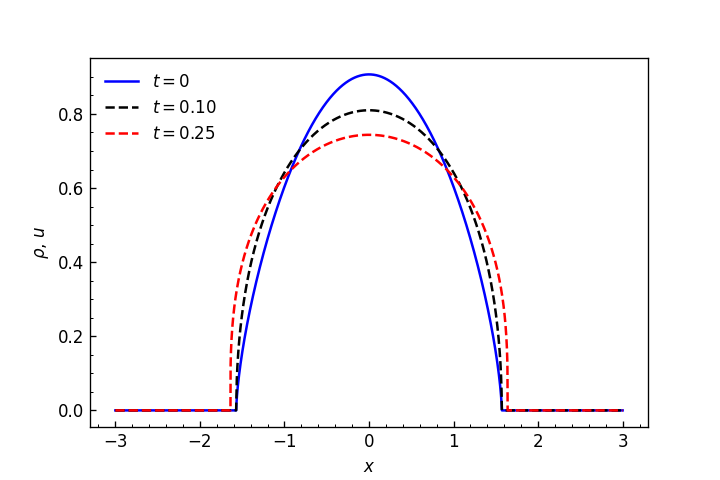

<IPython.core.display.Javascript object>


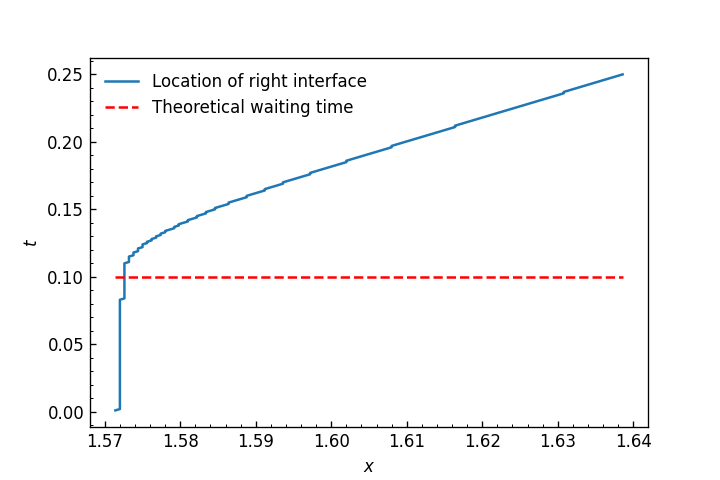

In [147]:
m=4
nx = 10000
dt = 1e-3
logDensity(m=m,dt0=dt,tstart=Parameter(0),tstop = .25,n0 = nx, plot=1)

 Time: 0.170, xR: 1.59810

<IPython.core.display.Javascript object>


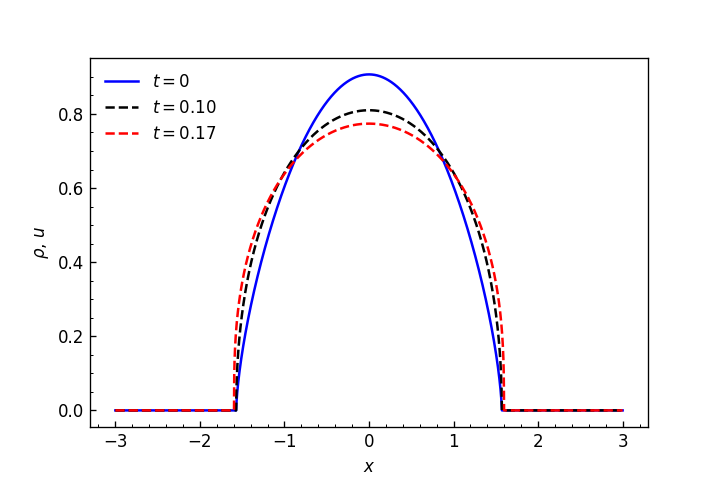

<IPython.core.display.Javascript object>


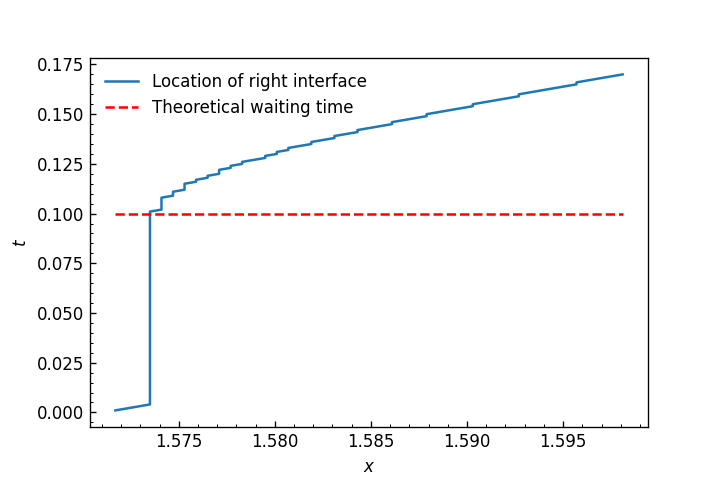

In [167]:
m=4
nx = 10000
dt = 1e-3
Mixed(m=m,dt0=dt,tstart=Parameter(0),tstop = .17,n0 = nx, plot=1)